In [1]:
from google.colab import files
uploaded = files.upload()

Saving XD.zip to XD.zip


In [2]:
import zipfile
with zipfile.ZipFile("XD.zip", "r") as z:
    z.extractall("/content/gender-class/")

## 3. Setup & pick one tracked image

Tracking: /content/gender-class/Training/female/131422.jpg.jpg


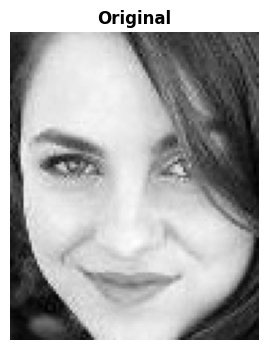

In [22]:
import cv2, os, glob, shutil
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform, filters

BASE_INPUT_PATH = "/content/gender-class/"
SUB_FOLDERS = ["Training/female", "Training/male", "Validation/female", "Validation/male"]
OUT_PREPROCESSED = "/content/stage1_preprocessed/"
OUT_FILTERED     = "/content/stage2_filtered/"
OUT_EDGE_SEG     = "/content/stage3_edge_seg/"
OUT_ZIP          = "/content/final_results"

RESIZE_DIM   = (128, 128)
GAUSS_SIGMA  = 1
GAUSS_KERNEL = (5, 5)
SHARP_KERNEL = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]])
SAMPLE_SIZE  = 1000
CANNY_T1, CANNY_T2 = 100, 200
THRESH_VALUE = 127

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

# Pick the very first readable image in the dataset — fixed, no randomness
TRACKED_RAW = None
for sub in SUB_FOLDERS:
    candidates = sorted(glob.glob(os.path.join(BASE_INPUT_PATH, sub, "*")))
    for fp in candidates:
        if cv2.imread(fp, 0) is not None:
            TRACKED_RAW = fp
            break
    if TRACKED_RAW:
        break

print(f"Tracking: {TRACKED_RAW}")
plt.figure(figsize=(4,4))
plt.imshow(cv2.imread(TRACKED_RAW, 0), cmap="gray")
plt.title("Original", fontweight="bold"); plt.axis("off"); plt.show()

## 4. Stage 1 — Grayscale · Resize · Gaussian Smooth

=== STAGE 1 ===
  [Training/female] done (skipped 0)
  [Training/male] done (skipped 0)
  [Validation/female] done (skipped 0)
  [Validation/male] done (skipped 0)
Stage 1 complete.

S1_PATH: /content/stage1_preprocessed/Training/female/131422.jpg.jpg  exists=True


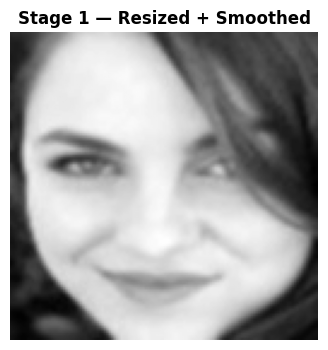

In [23]:
def stage1_preprocess():
    print("=== STAGE 1 ===")
    for sub in SUB_FOLDERS:
        out_sub = os.path.join(OUT_PREPROCESSED, sub)
        ensure_dir(out_sub)
        files_list = sorted(glob.glob(os.path.join(BASE_INPUT_PATH, sub, "*")))
        skipped = 0
        for fp in files_list:
            img = cv2.imread(fp, 0)
            if img is None: skipped += 1; continue
            img_r = transform.resize(img, RESIZE_DIM)
            img_e = filters.gaussian(img_r, sigma=GAUSS_SIGMA)
            cv2.imwrite(os.path.join(out_sub, os.path.basename(fp)), (img_e * 255).astype(np.uint8))
        print(f"  [{sub}] done (skipped {skipped})")
    print("Stage 1 complete.\n")

stage1_preprocess()

# Load tracked image from Stage 1 output — same subfolder, same filename
_sub = os.path.relpath(os.path.dirname(TRACKED_RAW), BASE_INPUT_PATH)
_fname = os.path.basename(TRACKED_RAW)
S1_PATH = os.path.join(OUT_PREPROCESSED, _sub, _fname)
print(f"S1_PATH: {S1_PATH}  exists={os.path.exists(S1_PATH)}")

s1_img = cv2.imread(S1_PATH, 0)
plt.figure(figsize=(4,4))
plt.imshow(s1_img, cmap="gray")
plt.title("Stage 1 — Resized + Smoothed", fontweight="bold"); plt.axis("off"); plt.show()

## 5. Stage 2 — Sharpening Filter

=== STAGE 2 ===
Stage 2 complete — 58658 images.

S2_PATH: /content/stage2_filtered/Training/female/filtered_131422.jpg.jpg  exists=True


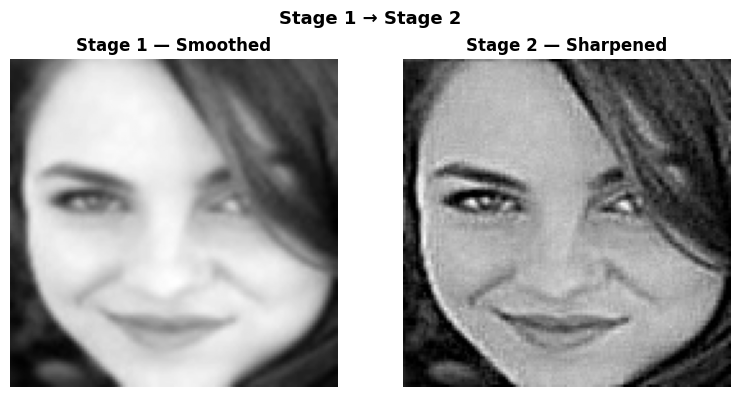

In [24]:
def stage2_filter():
    print("=== STAGE 2 ===")
    total = 0
    for root, _, files_list in os.walk(OUT_PREPROCESSED):
        for fname in files_list:
            if not fname.lower().endswith(('.png','.jpg','.jpeg')): continue
            img = cv2.imread(os.path.join(root, fname))
            if img is None: continue
            rel = os.path.relpath(root, OUT_PREPROCESSED)
            save_dir = os.path.join(OUT_FILTERED, rel)
            ensure_dir(save_dir)
            sharpened = cv2.filter2D(img, -1, SHARP_KERNEL)
            cv2.imwrite(os.path.join(save_dir, "filtered_" + fname), sharpened)
            total += 1
    print(f"Stage 2 complete — {total} images.\n")

stage2_filter()

# Stage 2 prepends "filtered_" to the Stage 1 filename
S2_PATH = os.path.join(OUT_FILTERED, _sub, "filtered_" + _fname)
print(f"S2_PATH: {S2_PATH}  exists={os.path.exists(S2_PATH)}")

s2_img = cv2.cvtColor(cv2.imread(S2_PATH), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(s1_img, cmap="gray"); axes[0].set_title("Stage 1 — Smoothed", fontweight="bold"); axes[0].axis("off")
axes[1].imshow(s2_img);              axes[1].set_title("Stage 2 — Sharpened", fontweight="bold"); axes[1].axis("off")
plt.suptitle("Stage 1 → Stage 2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Stage 3 — Edge Detection & Segmentation

=== STAGE 3 ===
Stage 3 complete — 1000 images. ZIP: /content/final_results.zip

S2_BASE: filtered_131422.jpg
sobel exists: True
canny exists: True
seg   exists: True


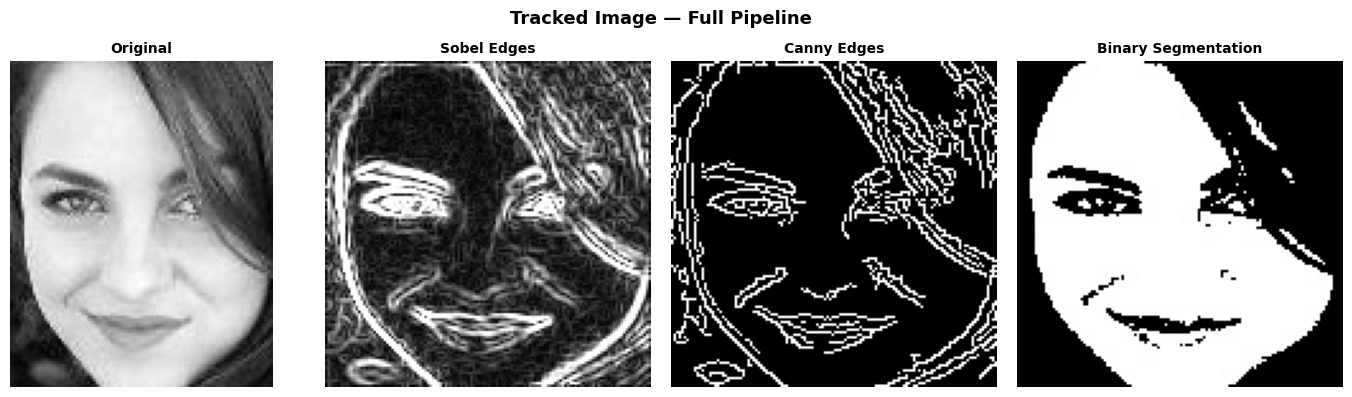

In [25]:
def stage3_edge_seg(must_include=None):
    print("=== STAGE 3 ===")
    if os.path.exists(OUT_EDGE_SEG): shutil.rmtree(OUT_EDGE_SEG)
    ensure_dir(OUT_EDGE_SEG)
    imgs = sorted(
        glob.glob(os.path.join(OUT_FILTERED, "**", "*.jpg"),  recursive=True) +
        glob.glob(os.path.join(OUT_FILTERED, "**", "*.jpeg"), recursive=True) +
        glob.glob(os.path.join(OUT_FILTERED, "**", "*.png"),  recursive=True)
    )
    # Always put the tracked image first so it's never cut off by SAMPLE_SIZE
    if must_include and must_include in imgs:
        imgs.remove(must_include)
    if must_include:
        imgs.insert(0, must_include)

    processed = 0
    for path in imgs[:SAMPLE_SIZE]:
        img = cv2.imread(path, 0)
        if img is None: continue
        base = os.path.splitext(os.path.basename(path))[0]
        sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        cv2.imwrite(f"{OUT_EDGE_SEG}{base}_sobel.jpg", cv2.convertScaleAbs(cv2.magnitude(sx, sy)))
        cv2.imwrite(f"{OUT_EDGE_SEG}{base}_canny.jpg", cv2.Canny(img, CANNY_T1, CANNY_T2))
        cv2.imwrite(f"{OUT_EDGE_SEG}{base}_seg.jpg",   cv2.threshold(img, THRESH_VALUE, 255, cv2.THRESH_BINARY)[1])
        processed += 1
    print(f"Stage 3 complete — {processed} images. ZIP: {shutil.make_archive(OUT_ZIP, 'zip', OUT_EDGE_SEG)}\n")

stage3_edge_seg(must_include=S2_PATH)

# Stage 3 strips only the LAST extension from the filename
# "filtered_face.jpg" → base = "filtered_face"  (os.path.splitext strips .jpg)
# but our S2 file is "filtered_face.jpg" so base = "filtered_face" ✓
S2_BASE = os.path.splitext(os.path.basename(S2_PATH))[0]
print(f"S2_BASE: {S2_BASE}")

sobel_path = f"{OUT_EDGE_SEG}{S2_BASE}_sobel.jpg"
canny_path = f"{OUT_EDGE_SEG}{S2_BASE}_canny.jpg"
seg_path   = f"{OUT_EDGE_SEG}{S2_BASE}_seg.jpg"

print(f"sobel exists: {os.path.exists(sobel_path)}")
print(f"canny exists: {os.path.exists(canny_path)}")
print(f"seg   exists: {os.path.exists(seg_path)}")

sobel_img = cv2.imread(sobel_path, 0)
canny_img = cv2.imread(canny_path, 0)
seg_img   = cv2.imread(seg_path,   0)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (im, title) in zip(axes, [
    (cv2.imread(TRACKED_RAW, 0), "Original"),
    (sobel_img,                  "Sobel Edges"),
    (canny_img,                  "Canny Edges"),
    (seg_img,                    "Binary Segmentation"),
]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.axis("off")
plt.suptitle("Tracked Image — Full Pipeline", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 7. Download results

In [26]:
from google.colab import files

# Download the ZIP (Stage 3 results)
files.download('/content/final_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>